In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#Define the sigmoid function
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [4]:
#Loss Function:Cross entropy loss
def compute_loss(y,hx):
    return -np.mean(y*np.log(hx)+(1-y)*np.log(1-hx))

In [5]:
#Gradient of the loss
def compute_gradient(X,y,hx):
    return np.dot(X.T,(hx-y))/y.shape[0]

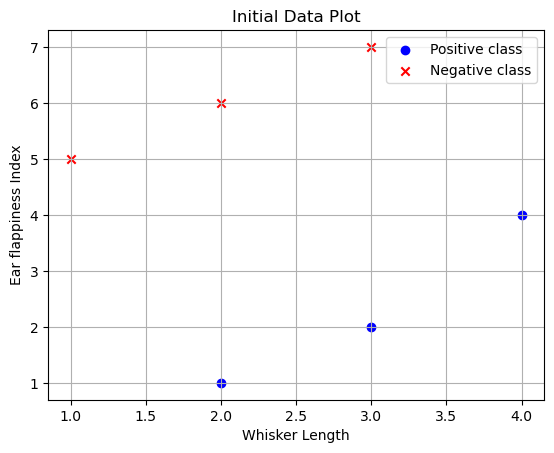

In [6]:
#Dataset
X=np.array([
    [2,1],
    [3,2],
    [4,4],
    [1,5],
    [2,6],
    [3,7],

])
y=np.array([1,1,1,0,0,0]) #labels

#plot iniyial data
plt.scatter(X[:3,0],X[:3,1], color="blue", marker="o", label="Positive class")
plt.scatter(X[3:,0],X[3:,1], color='red', marker='x', label="Negative class")
plt.title("Initial Data Plot")
plt.xlabel("Whisker Length")
plt.ylabel("Ear flappiness Index")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
#Logistic regression Model

def logistic_regression(X,y, learning_rate=0.1, num_iterations=15):
    #Add intercept term to X
    X=np.hstack((np.ones((X.shape[0],1)),X))

    #Intialize weights
    weights=np.zeros(X.shape[1])

    #Gradient Descent
    for i in range(num_iterations):
        z=np.dot(X, weights)
        hx=sigmoid(z)
        loss=compute_loss(y,hx)
        gradient=compute_gradient(X,y,hx)
        weights-=learning_rate*gradient

        plot_decision_boundary(X,y,weights, loss, i)
        
        print(f"Iterations{i}:Theta={weights}, Loss={loss}")

    return weights

In [8]:
#Plotting the function for decision boundary 
def plot_decision_boundary(X,y, weights, loss, iterations):
    plt.scatter(X[:3,1],X[:3,2], color="blue", marker="o", label="Positive class" if iterations==0 else"")
    plt.scatter(X[3:,1],X[3:,2], color='red', marker='x', label="Negative class" if iterations==0 else"")

    #Extend the x values a bit beyond the minimum and maximum values of the dataset
    x_values=np.array([np.min(X[:,1])-1, np.max(X[:,1])+1])
    y_values= -(weights[0]+weights[1]*x_values)/weights[2]
    plt.plot(x_values, y_values,"k")

    plt.xlim(x_values[0],x_values[1])
    plt.ylim(np.min(X[:,2])-1, np.max(X[:,2]+1))
    plt.xlabel("whisker Length")
    plt.ylabel("Ear Flappiness index")
    plt.title(f"Decision Boundary at iteration{iterations}\nLoss:{loss}")
    if iterations==0:
        plt.legend()
    plt.savefig("65.png")
    plt.show()


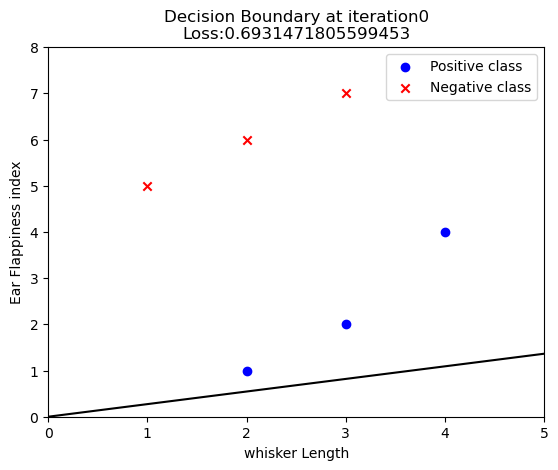

Iterations0:Theta=[ 0.          0.025      -0.09166667], Loss=0.6931471805599453


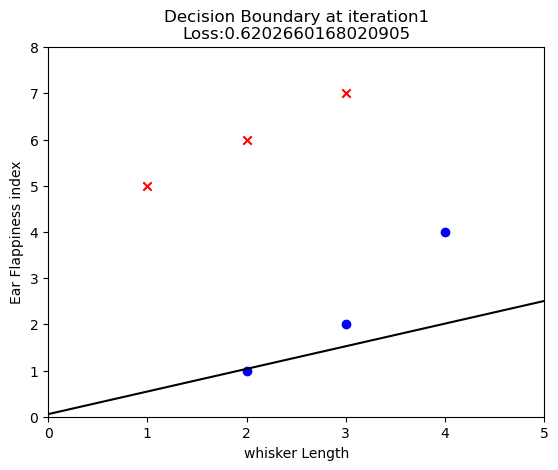

Iterations1:Theta=[ 0.00784781  0.06887779 -0.14060525], Loss=0.6202660168020905


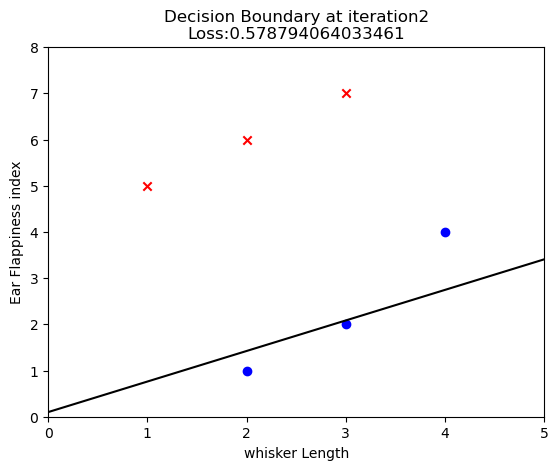

Iterations2:Theta=[ 0.01764134  0.11658362 -0.17629863], Loss=0.578794064033461


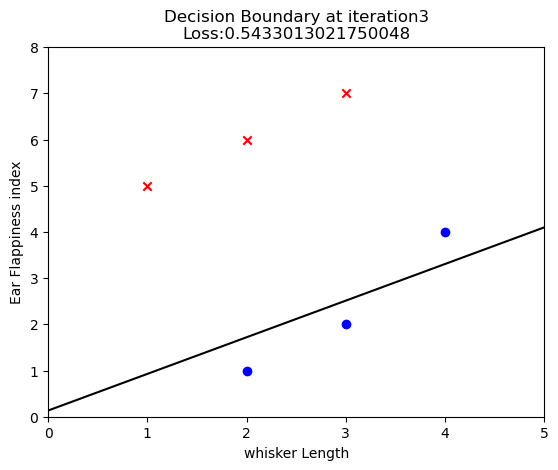

Iterations3:Theta=[ 0.02775584  0.16401158 -0.20689154], Loss=0.5433013021750048


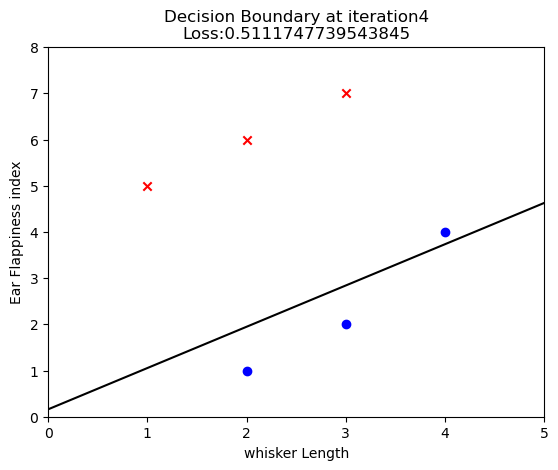

Iterations4:Theta=[ 0.03768945  0.20992896 -0.23499581], Loss=0.5111747739543845


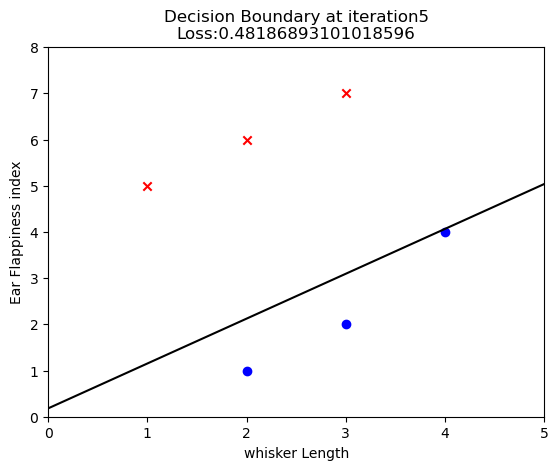

Iterations5:Theta=[ 0.04728565  0.25399034 -0.26154053], Loss=0.48186893101018596


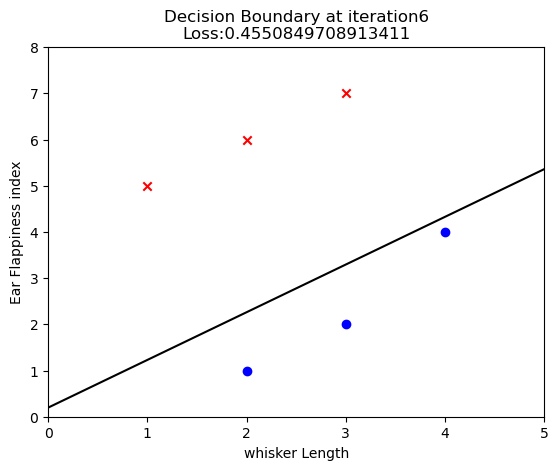

Iterations6:Theta=[ 0.0565048   0.29615111 -0.28688777], Loss=0.4550849708913411


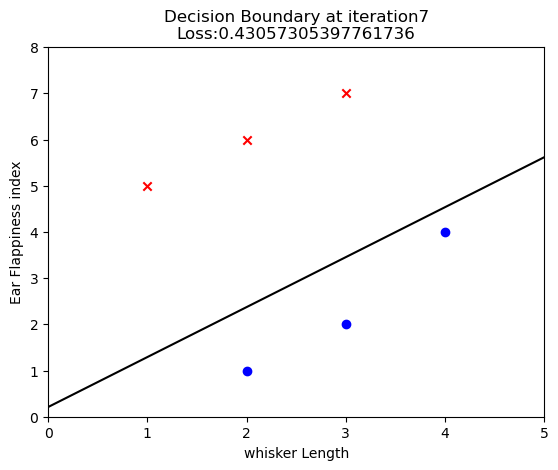

Iterations7:Theta=[ 0.06534809  0.33647087 -0.31119923], Loss=0.43057305397761736


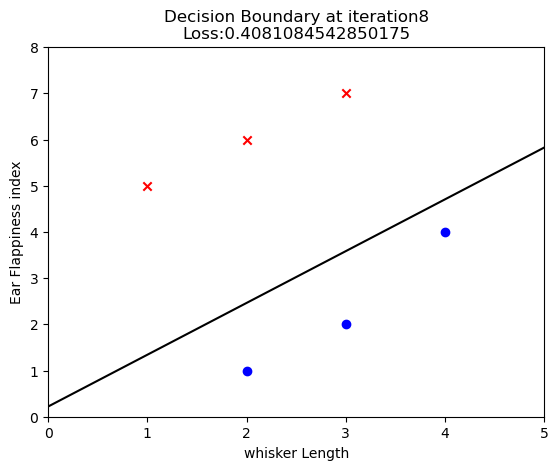

Iterations8:Theta=[ 0.07383072  0.37504349 -0.3345636 ], Loss=0.4081084542850175


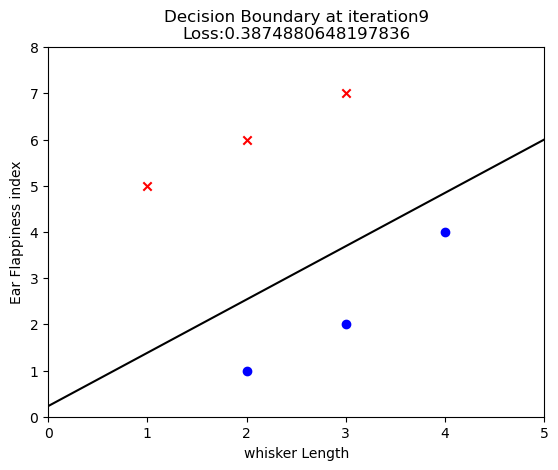

Iterations9:Theta=[ 0.08197221  0.41197135 -0.35704216], Loss=0.3874880648197836


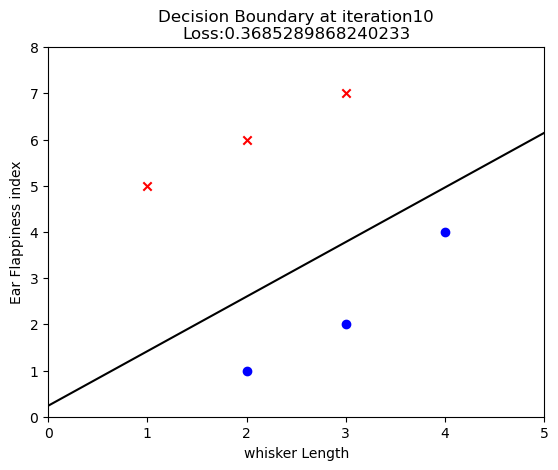

Iterations10:Theta=[ 0.08979277  0.44735586 -0.37868509], Loss=0.3685289868240233


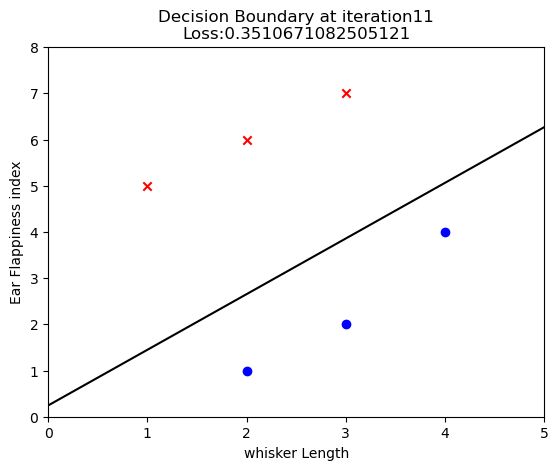

Iterations11:Theta=[ 0.097312    0.48129378 -0.39953748], Loss=0.3510671082505121


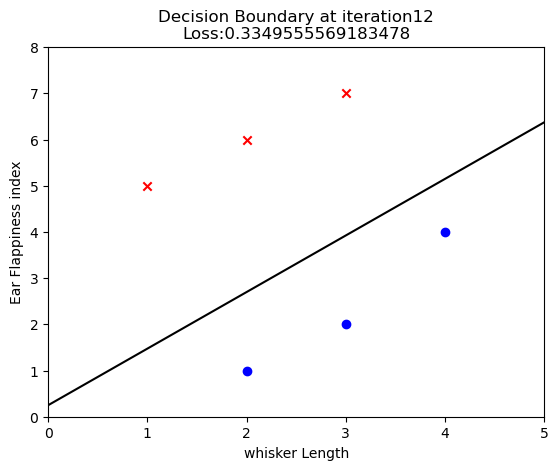

Iterations12:Theta=[ 0.10454842  0.51387608 -0.41964139], Loss=0.3349555569183478


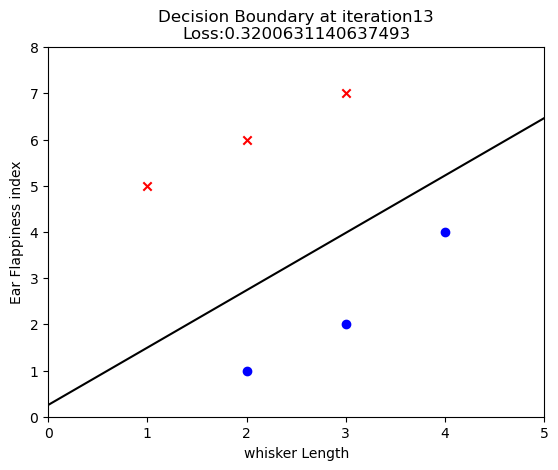

Iterations13:Theta=[ 0.11151934  0.54518765 -0.43903659], Loss=0.3200631140637493


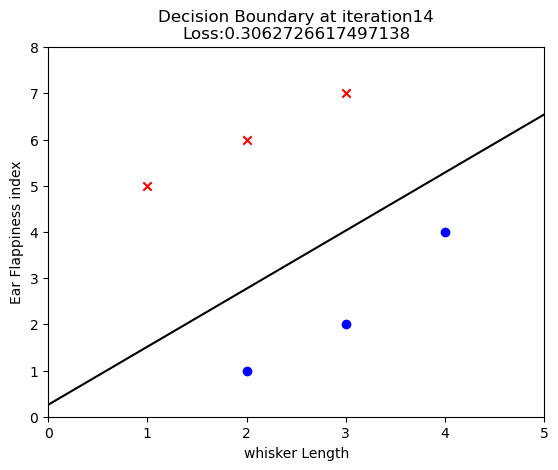

Iterations14:Theta=[ 0.11824083  0.57530738 -0.45776074], Loss=0.3062726617497138


In [9]:
#Training the model
weights=logistic_regression(X,y)